In [ ]:
print("hello world")

In [1]:
# mnist ocr classification
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch import nn
from torch import optim
import torch
import matplotlib.pyplot as plt

mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())

# data 확인하기

In [2]:
# data 확인
print(mnist_train)
print(mnist_test)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()
Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [3]:
mnist_test[0][0].shape

torch.Size([1, 28, 28])

In [4]:
mnist_train.data.shape

torch.Size([60000, 28, 28])

In [5]:
mnist_train.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

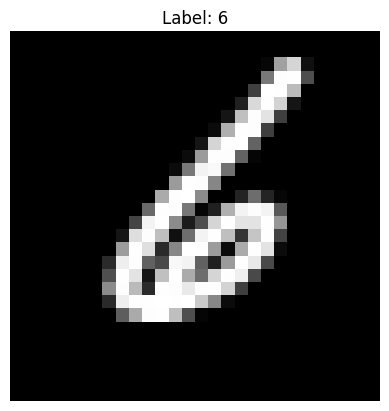

In [ ]:
# mnist dataset의 첫 번째 샘플을 확인
mnist_train[999]
# 이미지 데이터를 시각화
plt.imshow(mnist_train[999][0].squeeze(), cmap='gray') # 2D로 변환하여 시각화
plt.title(f"Label: {mnist_train[999][1]}") # 이미지의 레이블을 제목으로 표시
plt.axis('off') 
plt.show() # 이미지를 화면에 표시


In [ ]:
# data를 batch로 묶어서 모델에 입력
# train_loader와 test_loader는 각각 학습 데이터와 테스트 데이터를 배치 단위로 로드
train_loader = DataLoader(mnist_train, batch_size=64, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=64, shuffle=False)

In [ ]:
next(iter(train_loader))[0].shape # train_loader에서 첫 번째 배치를 가져옴

torch.Size([64, 1, 28, 28])

In [9]:
# 모델 설정하기
model = nn.Sequential(
    nn.Linear(784, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 10)
)

# 모델 만들기

In [ ]:
# class 로 모델 만들기
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(784, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 10)

    def forward(self, x):
        x = x.view(-1, 784) # 이미지 텐서를 1D 벡터로 변환
        x = torch.relu(self.fc1(x)) # 첫 번째 레이어와 ReLU 적용
        x = torch.relu(self.fc2(x)) # 두 번째 레이어와 ReLU 적용
        x = self.fc3(x) # 세 번째 레이어를 적용
        return x
    
model1 = MLP()

In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model1.to(device)

MLP(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=10, bias=True)
)

In [ ]:
# 모델 최적화
from torch import optim
criterion = nn.CrossEntropyLoss() # 손실 함수
optimizer = optim.Adam(model1.parameters(), lr=0.001) # Adam optimizer
losses = [] # 학습 과정에서 손실 값을 저장

# 모델 학습
num_epochs = 30
for epoch in range(num_epochs):
    model1.train() # 학습 모드
    for images, labels in train_loader: # train_loader에서 배치 단위로 이미지와 레이블을 가져옴
        images, labels = images.to(device), labels.to(device) # 이미지를 GPU로 이동
        outputs = model1(images) # 모델에 이미지를 입력
        loss = criterion(outputs, labels) # 출력과 실제 레이블 간의 손실
        optimizer.zero_grad() # 이전 단계에서 계산된 그래디언트 초기화
        images = torch.reshape(images, (-1, 784)) # 이미지를 1D 벡터로 변환
        loss.backward() # 손실에 대한 그래디언트 계산
        optimizer.step() # 모델의 매개변수를 업데이트하여 손실을 최소화
    losses.append(loss.item()) # 각 에포크의 손실 값을 리스트에 추가
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}") # 각 에포크마다 손실 값을 출력


Epoch [1/30], Loss: 0.5394
Epoch [2/30], Loss: 0.1550
Epoch [3/30], Loss: 0.0955
Epoch [4/30], Loss: 0.0115
Epoch [5/30], Loss: 0.0037
Epoch [6/30], Loss: 0.0512
Epoch [7/30], Loss: 0.1359
Epoch [8/30], Loss: 0.0608
Epoch [9/30], Loss: 0.0369
Epoch [10/30], Loss: 0.0093
Epoch [11/30], Loss: 0.0184
Epoch [12/30], Loss: 0.0092
Epoch [13/30], Loss: 0.0041
Epoch [14/30], Loss: 0.0020
Epoch [15/30], Loss: 0.0012
Epoch [16/30], Loss: 0.0008
Epoch [17/30], Loss: 0.0058
Epoch [18/30], Loss: 0.0007
Epoch [19/30], Loss: 0.0545
Epoch [20/30], Loss: 0.0052
Epoch [21/30], Loss: 0.0006
Epoch [22/30], Loss: 0.0587
Epoch [23/30], Loss: 0.0006
Epoch [24/30], Loss: 0.0066
Epoch [25/30], Loss: 0.0001
Epoch [26/30], Loss: 0.0012
Epoch [27/30], Loss: 0.0010
Epoch [28/30], Loss: 0.0001
Epoch [29/30], Loss: 0.0000
Epoch [30/30], Loss: 0.0047


In [13]:
print(losses)

[0.539358913898468, 0.1549842357635498, 0.09551781415939331, 0.011461073532700539, 0.0036673329304903746, 0.051153749227523804, 0.13585688173770905, 0.06077900156378746, 0.036876413971185684, 0.009271949529647827, 0.01844830997288227, 0.00919393077492714, 0.004084790125489235, 0.001964451279491186, 0.0011871299939230084, 0.0007855472504161298, 0.005835761781781912, 0.0007443205104209483, 0.05445791780948639, 0.00523942057043314, 0.0005641563329845667, 0.05868886038661003, 0.0005548350163735449, 0.006604841444641352, 8.58395651448518e-05, 0.0011564979795366526, 0.001004935591481626, 8.879204688128084e-05, 1.407965555699775e-05, 0.004705668892711401]


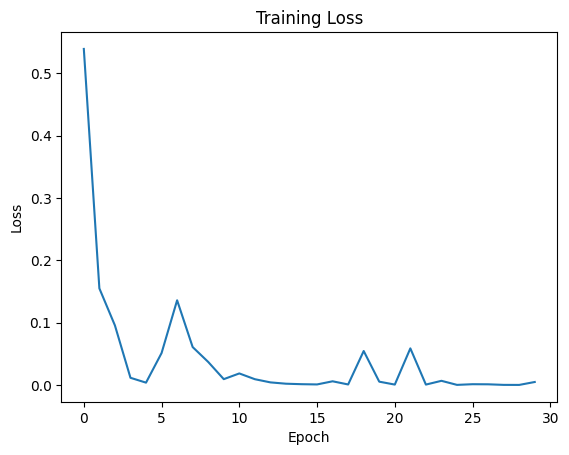

In [ ]:
# losses 시각화
from matplotlib import pyplot as plt
plt.plot(losses) # 손실 값을 그래프로 그림
plt.xlabel('Epoch') # x축 레이블
plt.ylabel('Loss') # y축 레이블
plt.title('Training Loss') # 제목
plt.show() # 그래프 표시


# 모델 평가

In [ ]:
# 모델 평가
model1.eval() # 평가 모드
with torch.no_grad(): # 그래디언트 계산 비활성화
    correct = 0
    total = 0 # 전체 샘플 수
    for images, labels in test_loader: # test_loader에서 배치 단위로 이미지와 레이블을 가져옴
        images = torch.reshape(images, (-1, 784)) # 벡터로 변환
        images, labels = images.to(device), labels.to(device) # 이미지를 GPU로 이동
        outputs = model1(images) # 모델에 이미지 입력
        _, predicted = torch.max(outputs.data, 1) # 클래스 인덱스 예측
        total += labels.size(0) # 전체 샘플 수 업데이트
        correct += (predicted == labels).sum().item() # 예측 성공 수
        print(f'Bat Acc: {100 * (predicted == labels).sum().item() / labels.size(0):.2f}%') # 정확도 출력
        print(f'Bat Cor: {(predicted == labels).sum().item()} / {labels.size(0)}') # 성공/전체 출력
        print(f'Bat Prd: {predicted.cpu().numpy()}') # 클래스 인덱스 출력
        print(f'Bat Lab: {labels.cpu().numpy()}') # 실제 레이블 출력
        print('---') # 구분선
        print(f'Cur Acc: {100 * correct / total:.2f}%') # 정확도 출력
        print(f'Cur Cor: {correct} / {total}') # 성공/전체 출력
        print('===') # 구분선

    print(f'Accuracy of the model on the test images: {100 * correct / total:.2f}%') # 모델의 정확도.


Bat Acc: 98.44%
Bat Cor: 63 / 64
Bat Prd: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1 3 1 3 4 7 2 7
 1 3 1 1 7 4 2 3 5 1 2 4 4 6 3 5 5 6 0 4 1 9 5 7 8 9 3]
Bat Lab: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1 3 1 3 4 7 2 7
 1 2 1 1 7 4 2 3 5 1 2 4 4 6 3 5 5 6 0 4 1 9 5 7 8 9 3]
---
Cur Acc: 98.44%
Cur Cor: 63 / 64
===
Bat Acc: 96.88%
Bat Cor: 62 / 64
Bat Prd: [7 4 6 4 3 0 7 0 2 9 1 7 3 2 9 7 7 6 2 7 8 4 7 3 6 1 3 6 9 3 1 4 1 7 6 9 6
 0 5 4 5 9 2 1 9 4 8 7 3 9 7 4 4 4 9 2 5 8 7 6 7 9 0 5]
Bat Lab: [7 4 6 4 3 0 7 0 2 9 1 7 3 2 9 7 7 6 2 7 8 4 7 3 6 1 3 6 9 3 1 4 1 7 6 9 6
 0 5 4 9 9 2 1 9 4 8 7 3 9 7 4 4 4 9 2 5 4 7 6 7 9 0 5]
---
Cur Acc: 97.66%
Cur Cor: 125 / 128
===
Bat Acc: 96.88%
Bat Cor: 62 / 64
Bat Prd: [8 5 6 6 5 7 8 1 0 1 6 4 6 7 3 1 7 1 8 2 0 8 9 8 5 5 1 5 6 0 3 4 4 6 5 4 6
 5 4 5 1 4 4 7 2 3 2 7 1 8 1 8 1 8 5 0 8 9 2 5 0 1 1 1]
Bat Lab: [8 5 6 6 5 7 8 1 0 1 6 4 6 7 3 1 7 1 8 2 0 2 9 9 5 5 1 5 6 0 3 4 4 6 5 4 6
 5 4 5 1 4 4 7 2 3 2 7 1 8 1 8 1 

In [16]:
print(device)

cuda


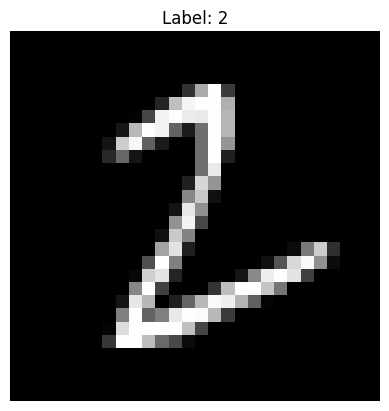

In [ ]:
mnist_test[38]
# 이미지 데이터 시각화
plt.imshow(mnist_test[38][0].squeeze(), cmap='gray') # 이미지 텐서를 2D로 변환
plt.title(f"Label: {mnist_test[38][1]}")
plt.axis('off') # 축 숨김
plt.show() # 화면에 표시